#### Análise de um Dataset com informações de vendas de jogos de videogame

#### Objetivos:
- Filtrar os jogos do ano de 2000
- Queremos apenas as informações cruciais
- Descobrir qual o top 5 jogos com maior valor de vendas nesse ano
- plotar um gráfico com os mesmos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Importar o dataset e armazenar no nosso DataFrame pandas
df = pd.read_csv('vgsales.csv').copy()


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [9]:
# Dropando as linhas sem dados completos

df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [12]:
# Dropando as linhas duplicadas

df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [15]:
# Corrigindo o dtype da coluna Year de float para int
# List Comprehension
df['Year'] = [
    int(ano) for ano in df['Year']
]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


In [27]:
# Filtrando o df para que só apresente os registros que sejam do ano 2000

df_2000 = df.loc[lambda df: df['Year'] == 2000]
df_2000

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
132,133,Pokémon Crystal Version,GB,2000,Role-Playing,Nintendo,2.55,1.56,1.29,0.99,6.39
173,174,Final Fantasy IX,PS,2000,Role-Playing,SquareSoft,1.62,0.77,2.78,0.14,5.30
223,224,Driver 2,PS,2000,Action,Atari,2.36,2.10,0.02,0.25,4.73
225,226,Tony Hawk's Pro Skater 2,PS,2000,Sports,Activision,3.05,1.41,0.02,0.20,4.68
242,243,Dragon Quest VII: Warriors of Eden,PS,2000,Role-Playing,Enix Corporation,0.20,0.14,4.10,0.02,4.47
...,...,...,...,...,...,...,...,...,...,...,...
15505,15508,Point Blank 3,PS,2000,Shooter,Namco Bandai Games,0.01,0.01,0.00,0.00,0.02
15651,15654,Airline Tycoon,PC,2000,Simulation,Interplay,0.00,0.01,0.00,0.00,0.02
16163,16166,Deus Ex,PC,2000,Role-Playing,Eidos Interactive,0.00,0.01,0.00,0.00,0.01
16518,16521,Crossroad Crisis,PS,2000,Puzzle,Success,0.01,0.00,0.00,0.00,0.01


In [3]:
# Filtrando por múltiplos critérios

# df_maior_2000_nintendo = df.loc[(df['Year'] > 2000) & (df['Publisher'] == 'Nintendo')]
# df_maior_2000_nintendo

In [4]:
# Ordenando os registros pelas vendas globais

df_2000 = df_2000.sort_values(by=['Global_Sales'])

NameError: name 'df_2000' is not defined

In [34]:
# Removendo as colunas não essenciais

df_2000 = df_2000.drop([
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'
], axis=1)

In [37]:
# Pegar os 5 últimos jogos, que osmais vendidos, de acordo com a formas com a qual ordenamos

top_jogos_2000 = df_2000.tail()

In [41]:
top_jogos_2000['Global_Sales'].describe()

count    5.000000
mean     5.114000
std      0.776743
min      4.470000
25%      4.680000
50%      4.730000
75%      5.300000
max      6.390000
Name: Global_Sales, dtype: float64

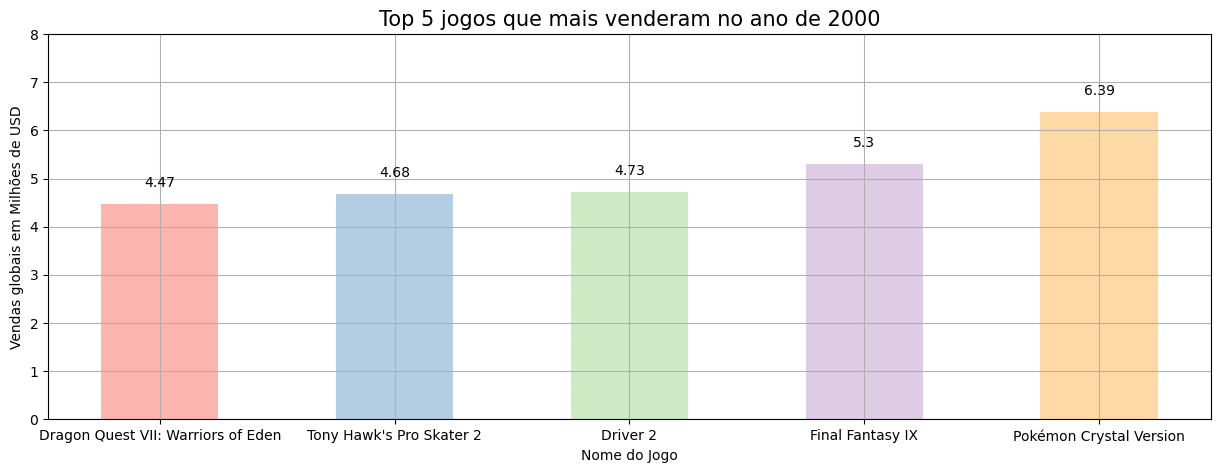

In [48]:
# Geração do gráfico

fig, ax = plt.subplots(figsize=(15, 5))

g = ax.bar(top_jogos_2000['Name'], top_jogos_2000['Global_Sales'], width=.5,
          color=sns.mpl_palette('Pastel1')
          )
ax.set_title('Top 5 jogos que mais venderam no ano de 2000', fontsize=15)
ax.set(
    xlabel='Nome do Jogo',
    ylabel='Vendas globais em Milhões de USD',
    ylim=(0, 8)
)
ax.grid()
ax.bar_label(g, padding=10)
plt.show()